In [ ]:
# ── Standard Library ────────────────────────────────────────────
import math
import time
import glob
import re
from pathlib import Path

# ── Numerical & Data ────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy.interpolate import griddata
import scipy.optimize
from scipy.stats import norm, qmc
from numba import njit
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Deep Learning ────────────────────────────────────────────────
import tensorflow as tf
import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, InputLayer
from keras.callbacks import EarlyStopping

# ── Visualisation ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# ── Widgets ──────────────────────────────────────────────────────
import ipywidgets as widgets
from ipywidgets import interact

%matplotlib inline

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

FIT_MODE = True

maturities = np.array([0.019, 0.038, 0.057, 0.082, 0.164, 0.246, 0.493, 0.739, 1.0])
maturities_dim = len(maturities)

# Strikes adaptés à chaque maturité : K_j = exp(z_j * sigma_ref * sqrt(T))
sigma_ref = 0.08        # vol ATM de référence EUR/USD
z_scores  = np.linspace(-2.5, 2.5, 11)
strikes_dim = len(z_scores)

def get_strikes(T):
    return np.exp(z_scores * sigma_ref * np.sqrt(T))

def get_log_moneyness(T):
    return z_scores * sigma_ref * np.sqrt(T)

# Bornes des paramètres rBergomi : xi = variance initiale (vol ATM ≈ sqrt(xi))
ub = [0.010] * 9 + [2.5,  0.8, 0.5]
lb = [0.001] * 9 + [0.3, -0.8, 0.025]

Tu as tout à fait raison d'avoir ce réflexe ! Si tu calculais $\xi = \frac{K}{T}$, ce serait une catastrophe numérique. Mais attention, la formule de normalisation utilise le Log-Moneyness et la racine carrée du temps :$$\xi = \frac{\ln(K/S_0)}{\sqrt{T}}$$Voici pourquoi cette transformation est justement la solution à ton problème de "0.80 à 1 jour" :1. L'effet "Zoom" automatiqueTon intuition est bonne : à $T = 0.003$ (1 jour), un moneyness de $0.80$ est une aberration statistique (environ 40 écarts-types !).

In [ ]:
@njit(fastmath=True, cache=True)
def norm_cdf(x):
    return 0.5 * (1.0 + math.erf(x / 1.4142135623730951))

@njit(fastmath=True, cache=True)
def bs_call_price_numba(S, K, T, r, vol):
    d1 = (math.log(S / K) + (r + 0.5 * vol**2) * T) / (vol * math.sqrt(T))
    d2 = d1 - vol * math.sqrt(T)
    return S * norm_cdf(d1) - K * math.exp(-r * T) * norm_cdf(d2)

@njit(fastmath=True, cache=True)
def implied_volatility_numba(target_price, S, K, T, r=0.0):
    intrinsic = max(S - K, 0.0)
    if target_price <= intrinsic:
        return 0.001
    low, high = 1e-3, 3.0
    for _ in range(50):
        mid = (low + high) / 2.0
        if bs_call_price_numba(S, K, T, r, mid) > target_price:
            high = mid
        else:
            low = mid
    return (low + high) / 2.0

@njit(fastmath=True, cache=True)
def rough_bergomi_mc_pricer(params, maturities, z_scores, sigma_ref,
                            S0=1.0, paths=10000, steps_per_year=100):
    xi_array = params[:9]
    nu, rho, H = params[9], params[10], params[11]

    T_max = maturities[-1]
    total_steps = int(T_max * steps_per_year)
    dt = T_max / total_steps

    time_grid = np.zeros(total_steps)
    for i in range(total_steps):
        time_grid[i] = dt * (i + 1)

    # Interpolation constante par morceaux de xi sur la grille de maturités
    xi_t = np.zeros(total_steps)
    for i in range(total_steps):
        bucket_idx = np.searchsorted(maturities, time_grid[i], side='left')
        bucket_idx = min(bucket_idx, len(xi_array) - 1)
        if bucket_idx > 0 and time_grid[i] < maturities[bucket_idx]:
            bucket_idx -= 1
        xi_t[i] = xi_array[bucket_idx]

    dZ      = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW_perp = np.random.normal(0.0, math.sqrt(dt), (paths, total_steps))
    dW      = rho * dZ + math.sqrt(1.0 - rho**2) * dW_perp

    # Processus de Volterra Y via noyau de Riemann-Liouville
    Y = np.zeros((paths, total_steps))
    gamma_kernel = np.zeros(total_steps)
    for k in range(1, total_steps + 1):
        gamma_kernel[k-1] = ((k - 0.5) * dt)**(H - 0.5)

    sqrt_2H = math.sqrt(2.0 * H)
    for p in range(paths):
        for i in range(total_steps):
            sum_Z = 0.0
            for k in range(i + 1):
                sum_Z += dZ[p, k] * gamma_kernel[i - k]
            Y[p, i] = sqrt_2H * sum_Z

    t_2H = np.zeros(total_steps)
    for i in range(total_steps):
        t_2H[i] = time_grid[i]**(2.0 * H)

    V = np.zeros((paths, total_steps))
    for i in range(total_steps):
        for p in range(paths):
            V[p, i] = xi_t[i] * math.exp(nu * Y[p, i] - 0.5 * (nu**2) * t_2H[i])

    X_log = np.zeros((paths, total_steps + 1))
    for i in range(total_steps):
        for p in range(paths):
            X_log[p, i+1] = X_log[p, i] - 0.5 * V[p, i] * dt + math.sqrt(V[p, i]) * dW[p, i]

    S = np.zeros((paths, total_steps + 1))
    for p in range(paths):
        for i in range(total_steps + 1):
            S[p, i] = S0 * math.exp(X_log[p, i])

    # Correction martingale
    for i in range(1, total_steps + 1):
        mean_S = 0.0
        for p in range(paths):
            mean_S += S[p, i]
        mean_S /= paths
        for p in range(paths):
            S[p, i] = S[p, i] * (S0 / mean_S)

    n_strikes = len(z_scores)
    vol_grid = np.zeros((len(maturities), n_strikes))
    for i in range(len(maturities)):
        T = maturities[i]
        step_idx = max(1, int(round(T * steps_per_year)))
        S_T = S[:, step_idx]
        for j in range(n_strikes):
            K = math.exp(z_scores[j] * sigma_ref * math.sqrt(T))
            mc_price = 0.0
            for p in range(paths):
                mc_price += max(S_T[p] - K, 0.0)
            mc_price /= paths
            vol_grid[i, j] = implied_volatility_numba(mc_price, S0, K, T, 0.0)

    return vol_grid


def simulate_single_scenario(current_params, maturities, z_scores, sigma_ref):
    return rough_bergomi_mc_pricer(
        current_params, maturities, z_scores, sigma_ref,
        S0=1.0, paths=10000, steps_per_year=500
    ).flatten()

In [13]:
def generate_samples_sobol(num_samples, lb, ub):
    sampler = qmc.Sobol(d=len(lb), scramble=True, seed=42)
    sample  = sampler.random(num_samples)
    return qmc.scale(sample, lb, ub)

if FIT_MODE:
    num_samples  = 60000
    X_parameters = generate_samples_sobol(num_samples, lb, ub)

    _ = simulate_single_scenario(X_parameters[0], maturities, z_scores, sigma_ref)  # Warmup JIT

    start_time = time.time()
    Y_volatilities = Parallel(n_jobs=-1, verbose=10, batch_size=100)(
        delayed(simulate_single_scenario)(X_parameters[i], maturities, z_scores, sigma_ref)
        for i in range(num_samples)
    )
    print(f"Simulation terminée en {time.time() - start_time:.2f}s")

    param_columns = [f'xi_{m}' for m in maturities] + ['nu', 'rho', 'H']
    vol_columns   = [f'vol_T{t:.3f}_Z{j}' for t in maturities for j in range(strikes_dim)]
    dataset = pd.concat([
        pd.DataFrame(X_parameters,  columns=param_columns),
        pd.DataFrame(Y_volatilities, columns=vol_columns)
    ], axis=1)
    dataset.to_csv("rough_bergomi_training_data_zscores.csv", index=False)
    print(f"Données sauvegardées : {num_samples} scénarios.")
else:
    dataset = pd.read_csv("rough_bergomi_training_data_zscores.csv")
    print(f"{len(dataset)} échantillons chargés.")

# Features : 12 paramètres rBergomi — Labels : 99 vols (9 maturités × 11 strikes)
X = dataset.iloc[:, :12].values
Y = dataset.iloc[:, 12:].values

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.15, random_state=42)

# Scaling linéaire des paramètres vers [-1, 1]
ub_arr         = np.array(ub)
lb_arr         = np.array(lb)
mid_arr        = 0.5 * (ub_arr + lb_arr)
half_range_arr = 0.5 * (ub_arr - lb_arr)

def myscale(x):
    return (x - mid_arr) / half_range_arr

def myinverse(x):
    return x * half_range_arr + mid_arr

x_train_transform = (x_train - mid_arr) / half_range_arr
x_test_transform  = (x_test  - mid_arr) / half_range_arr

# StandardScaler sur les surfaces de vol (moyenne 0, variance 1)
scale2 = StandardScaler()
y_train_transform = scale2.fit_transform(y_train)
y_test_transform  = scale2.transform(y_test)

def xinversetransform(x):
    return scale2.inverse_transform(x.reshape(1, -1))[0]

5000 échantillons chargés.


In [14]:
# Poids par maturité : les courtes maturités (plus difficiles à fitter) ont un poids plus élevé
def compute_weight(T):
    return 1.0 if T >= 1.0 else 2.0 - T

num_total_outputs = 99
num_maturities    = len(maturities)
num_strikes       = num_total_outputs // num_maturities

weights_list = []
for T in maturities:
    w = compute_weight(T)
    for _ in range(num_strikes):
        weights_list.append(w)

weights_array        = np.array(weights_list, dtype=np.float32)
loss_weights_tensor  = tf.constant(weights_array)

@tf.keras.utils.register_keras_serializable()
def weighted_mse(y_true, y_pred):
    squared_errors = tf.square(y_true - y_pred)
    weighted_errors = squared_errors * loss_weights_tensor # (pondération désactivée)
    return tf.reduce_mean(weighted_errors, axis=-1)

if FIT_MODE:
    modelGEN = Sequential([
        InputLayer(input_shape=(12,)),
        Dense(60, activation='elu'),
        Dense(60, activation='elu'),
        Dense(60, activation='elu'),
        Dense(60, activation='elu'),
        Dense(99, activation='linear')
    ])

    modelGEN.compile(loss=weighted_mse, optimizer="adam")

    earlystop = EarlyStopping(monitor="val_loss", patience=30, verbose=1, mode="min")

    modelGEN.fit(x_train_transform, y_train_transform, batch_size=64,
                 validation_data=(x_test_transform, y_test_transform),
                 epochs=600, verbose=True, shuffle=True, callbacks=[earlystop])

    modelGEN.save("rough_bergomi_eurusd_model.keras")
    print("Modèle sauvegardé : 'rough_bergomi_eurusd_model.keras'")
else:
    # custom_objects requis pour désérialiser la loss custom
    modelGEN = load_model("rough_bergomi_eurusd_model.keras",
                          custom_objects={'weighted_mse': weighted_mse})
    print(f"Modèle chargé : {len(dataset)} échantillons.")

modelGEN.summary()

Modèle chargé : 5000 échantillons.


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 60)             │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 60)             │         3,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 99)             │         6,039 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,399 (208.59 KB)

 Trainable params: 17,799 (69.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 35,600 (139.07 KB)

In [15]:
# Extraction des poids entraînés vers numpy pour le pricer/gradient numba
NNParameters = []
for layer in modelGEN.layers:
    weights = layer.get_weights()
    if weights:
        NNParameters.append([np.ascontiguousarray(w, dtype=np.float64) for w in weights])

# 4 couches cachées (elu) + 1 couche de sortie (linear)
W = [NNParameters[i][0] for i in range(5)]
b = [NNParameters[i][1] for i in range(5)]
NUM_HIDDEN = 4

def elu(x):
    return np.where(x >= 0, x, np.expm1(x))

def elu_prime(x):
    return np.where(x >= 0, 1.0, np.exp(x))

def NeuralNetwork(x):
    a = x
    for i in range(NUM_HIDDEN):
        a = elu(a @ W[i] + b[i])
    return a @ W[NUM_HIDDEN] + b[NUM_HIDDEN]

def NeuralNetworkGradient(x):
    """Jacobien analytique d(output)/d(input) par backprop, shape (12, 99)."""
    a = x
    Z = []
    for i in range(NUM_HIDDEN):
        z = a @ W[i] + b[i]
        Z.append(z)
        a = elu(z)

    grad = W[NUM_HIDDEN]
    for i in range(NUM_HIDDEN - 1, -1, -1):
        grad = elu_prime(Z[i])[:, np.newaxis] * grad
        grad = W[i] @ grad

    return grad

In [ ]:
def plot_func(xi0, nu, rho, H):
    full_params = np.array([xi0]*9 + [nu, rho, H])
    x0     = myscale(full_params)
    Smiles = xinversetransform(NeuralNetwork(x0))

    plt.figure(1, figsize=(15, 10))
    for i in range(maturities_dim):
        plt.subplot(3, 4, i+1)
        T  = maturities[i]
        lm = get_log_moneyness(T)   # axe x adaptatif à la maturité
        plt.plot(lm, Smiles[i*strikes_dim:(i+1)*strikes_dim], '*b', label="NN Approx")
        plt.ylim(0.02, 0.25)
        plt.title(f"Maturity={T:.3f}")
        plt.xlabel("log-moneyness (z·σ·√T)")
        plt.ylabel("Implied vol")
        plt.legend()
    plt.tight_layout()
    plt.show()

interact(plot_func,
         xi0 = widgets.FloatSlider(value=0.05, min=0.01, max=0.30, step=0.01),
         nu  = widgets.FloatSlider(value=1.5,  min=0.3,  max=2.5,  step=0.1),
         rho = widgets.FloatSlider(value=-0.1, min=-0.8,  max=0.8,  step=0.05),
         H   = widgets.FloatSlider(value=0.1,  min=0.025, max=0.5,  step=0.025))

interactive(children=(FloatSlider(value=0.05, description='xi0', max=0.3, min=0.01, step=0.01), FloatSlider(va…

<function __main__.plot_func(xi0, nu, rho, H)>

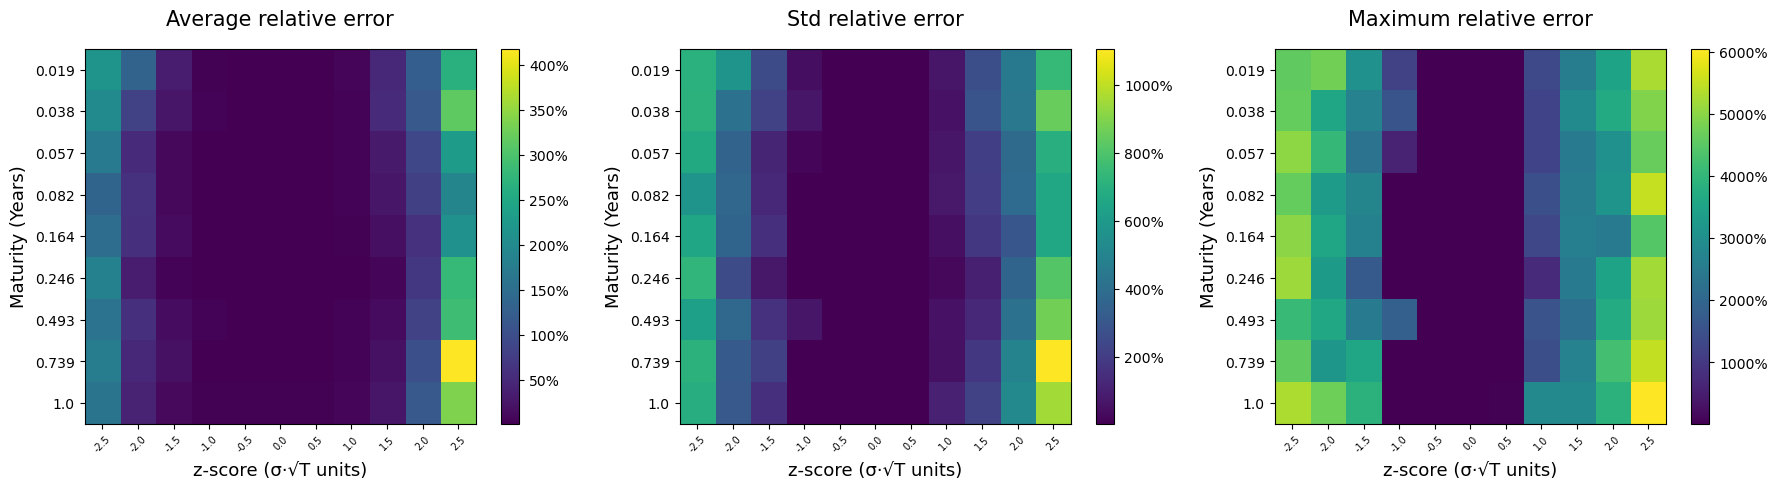

In [17]:
X_sample = x_test_transform
y_true   = y_test

prediction = np.array([xinversetransform(NeuralNetwork(X_sample[i])) for i in range(len(X_sample))])

z_labels = np.round(z_scores, 2)
errors = {
    "Average relative error": np.mean(100 * np.abs((y_true - prediction) / y_true), axis=0),
    "Std relative error":      100 * np.std(np.abs((y_true - prediction) / y_true), axis=0),
    "Maximum relative error":  100 * np.max(np.abs((y_true - prediction) / y_true), axis=0),
}

plt.figure(1, figsize=(18, 5))
for plot_idx, (title, err) in enumerate(errors.items()):
    ax = plt.subplot(1, 3, plot_idx + 1)
    plt.title(title, fontsize=15, y=1.04)
    plt.imshow(err.reshape(maturities_dim, strikes_dim), aspect='auto')
    plt.colorbar(format=mtick.PercentFormatter())
    ax.set_xticks(np.arange(strikes_dim))
    ax.set_xticklabels(z_labels, rotation=45, fontsize=7)
    ax.set_yticks(np.arange(maturities_dim))
    ax.set_yticklabels(np.round(maturities, 3))
    plt.xlabel("z-score (σ·√T units)", fontsize=13, labelpad=5)
    plt.ylabel("Maturity (Years)",      fontsize=13, labelpad=5)

plt.tight_layout()
plt.savefig('rBergomi_EURUSD_NNErrors.PNG', dpi=300, bbox_inches='tight')
plt.show()

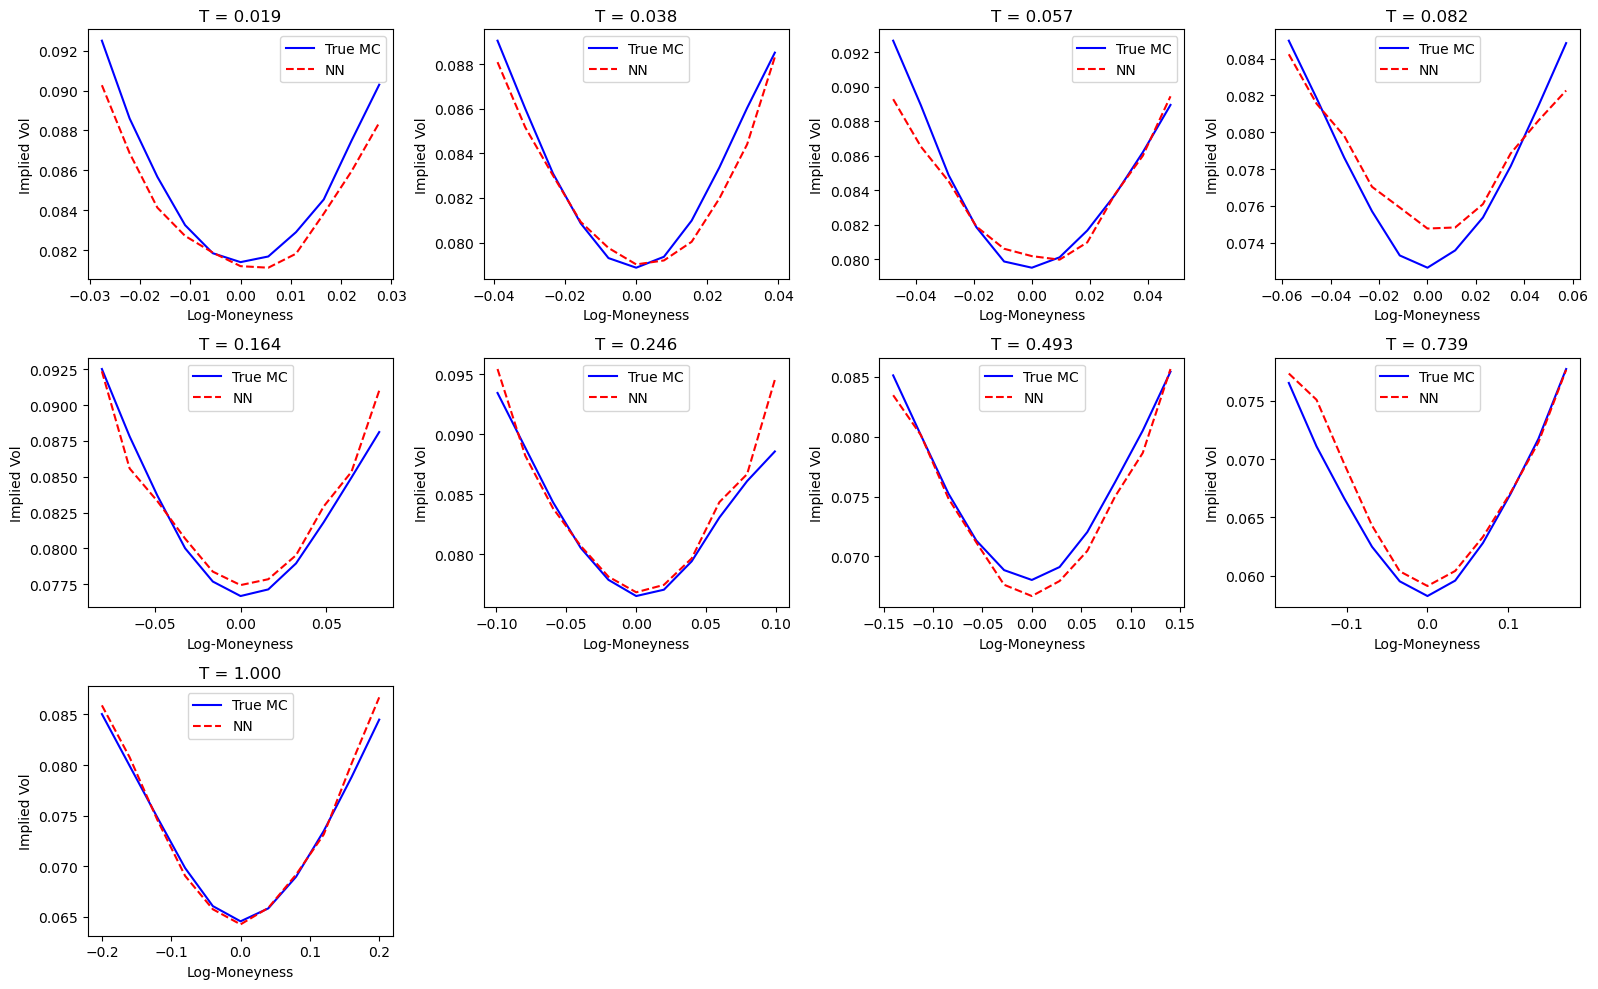

--- rBergomi sample #145 ---
xi  : [0.0074 0.0084 0.0031 0.0079 0.0072 0.004  0.0012 0.0085 0.0037]
nu  : 1.3391
rho : -0.0188
H   : 0.1235


In [18]:
S0 = 1.0
sample_ind = 145

X_sample   = x_test_transform[sample_ind]
prediction = xinversetransform(NeuralNetwork(X_sample))
y_true     = y_test[sample_ind]

cols = 4
rows = (maturities_dim + cols - 1) // cols

plt.figure(1, figsize=(16, 10))
for i in range(maturities_dim):
    plt.subplot(rows, cols, i+1)
    T  = maturities[i]
    lm = get_log_moneyness(T)
    plt.plot(lm, y_true[i*strikes_dim:(i+1)*strikes_dim],       'b',  label="True MC")
    plt.plot(lm, prediction[i*strikes_dim:(i+1)*strikes_dim], '--r',  label="NN")
    plt.title(f"T = {T:.3f}")
    plt.xlabel("Log-Moneyness")
    plt.ylabel("Implied Vol")
    plt.legend()

plt.tight_layout()
plt.show()

vrais_parametres = myinverse(X_sample)
print(f"--- rBergomi sample #{sample_ind} ---")
print(f"xi  : {np.round(vrais_parametres[:9], 4)}")
print(f"nu  : {vrais_parametres[9]:.4f}")
print(f"rho : {vrais_parametres[10]:.4f}")
print(f"H   : {vrais_parametres[11]:.4f}")

In [19]:
def CostFunc(x, sample_ind):
    return np.sum(np.power((NeuralNetwork(x) - y_test_transform[sample_ind]), 2))

def Jacobian(x, sample_ind):
    # sum sur axis=1 (les 99 sorties) → gradient de taille (12,)
    return 2 * np.sum((NeuralNetwork(x) - y_test_transform[sample_ind]) * NeuralNetworkGradient(x), axis=1)

def CostFuncLS(x, sample_ind):
    # Vecteur des résidus de taille (99,) requis par Levenberg-Marquardt
    return (NeuralNetwork(x) - y_test_transform[sample_ind])

def JacobianLS(x, sample_ind):
    # Transposée (99, 12) : LM exige (nb_résidus, nb_paramètres)
    return NeuralNetworkGradient(x).T

In [20]:
CalibratedParameters = []
Timing = []

init     = np.zeros(12)  # point initial dans l'espace normalisé [-1, 1]
num_tests = min(500, len(y_test_transform))

print("Starting Levenberg-Marquardt calibration...")

for i in range(num_tests):
    start = time.perf_counter()
    I = scipy.optimize.least_squares(CostFuncLS, init, JacobianLS, args=(i,), gtol=1e-10)
    end = time.perf_counter()

    CalibratedParameters.append(myinverse(I.x))
    Timing.append(end - start)

print(f"Calibration terminée — temps moyen : {np.mean(Timing)*1000:.2f} ms")

Starting Levenberg-Marquardt calibration...
Calibration terminée — temps moyen : 12.31 ms


In [22]:
def compile_fx_data(base_path, start_date, end_date, output_filename="Master_FX_London3PM.csv"):
    start_dt = pd.to_datetime(start_date)
    end_dt   = pd.to_datetime(end_date)
    root_dir = Path(base_path)

    all_csv_files = list(root_dir.rglob("*London_3PM_*.csv"))
    print(f"{len(all_csv_files)} fichiers London_3PM trouvés. Filtrage par date...")

    # Harmonisation des noms de colonnes entre les millésimes de fichiers
    rename_mapping = {
        'symbol': 'tenor', 'expires': 'expiry_date',
        'mide10d': 'mid10d', 'rr25d': 'mid25rr', 'rr10d': 'mid10rr',
        'bf25d': 'mid25bf', 'bf10d': 'mid10bf'
    }
    cols_to_keep = [
        'quote_date', 'tenor', 'dte', 'forward',
        'mid10d', 'mid25d', 'mid50d', 'mid75d', 'mid90d'
    ]

    dataframes     = []
    files_processed = 0

    for file_path in all_csv_files:
        match = re.search(r'London_3PM_(\d{8})\.csv$', file_path.name)
        if not match:
            continue

        file_date = pd.to_datetime(match.group(1), format='%Y%m%d')
        if not (start_dt <= file_date <= end_dt):
            continue

        try:
            df = pd.read_csv(file_path)
            df.columns = df.columns.str.strip().str.lower()
            df = df.rename(columns=rename_mapping)
            df['quote_date'] = file_date
            df = df[[c for c in cols_to_keep if c in df.columns]]
            dataframes.append(df)
            files_processed += 1
            if files_processed % 100 == 0:
                print(f"{files_processed} fichiers traités...")
        except Exception as e:
            print(f"Erreur lecture {file_path.name}: {e}")

    if not dataframes:
        print("Aucun fichier trouvé dans cette plage de dates.")
        return None

    master_df = pd.concat(dataframes, ignore_index=True)
    master_df.to_csv(output_filename, index=False)
    print(f"Sauvegardé : {output_filename} ({len(master_df)} lignes)")
    return master_df


my_base_folder = r"C:/Users/ERWAN/OneDrive/Documents/ENSAE/3ème année/S2/ML_finance/FXTOOL_EUU"
master_dataset = compile_fx_data(my_base_folder, start_date="2021-06-08", end_date="2026-04-13")

1227 fichiers London_3PM trouvés. Filtrage par date...
100 fichiers traités...
200 fichiers traités...
300 fichiers traités...
400 fichiers traités...
500 fichiers traités...
600 fichiers traités...
700 fichiers traités...
800 fichiers traités...
900 fichiers traités...
1000 fichiers traités...
1100 fichiers traités...
1200 fichiers traités...
Sauvegardé : Master_FX_London3PM.csv (12270 lignes)


Bien sûr ! Voici le rappel de la formule mathématique exacte, suivi de son implémentation en Python prête à être insérée dans ta boucle.1. La Formule Mathématique Exacte (Delta vers Moneyness)Sur le marché des devises (Forex), l'inversion de la formule de Garman-Kohlhagen (le Black-Scholes des devises) pour passer du Delta au Log-Moneyness ($k = \ln(K/F)$) s'écrit ainsi :$$k = -\sigma \sqrt{T} \Phi^{-1}(\Delta) + \frac{1}{2}\sigma^2 T$$Où :$k$ est le log-moneyness.$\sigma$ est la volatilité implicite (le vol ou mid).$T$ est la maturité en années.$\Delta$ est le Delta du Call (ex: 0.25 pour le 25D).$\Phi^{-1}$ est la fonction inverse de la répartition de la loi normale (qui nous donne le "z-score").Pour retrouver le Moneyness classique ($K/F$), il suffit de prendre l'exponentielle :$$\text{Moneyness} = \exp(k)$$2. Le Code Python (delta_to_moneyness)Voici la fonction Python ultra-optimisée qui traduit cette équation. Tu peux la placer tout en haut de ton script, juste après tes imports.

In [23]:
def delta_to_moneyness_vectorized(delta, vol_series, T_series):
    """
    Conversion Delta → Moneyness (K/F), convention Forex Delta Forward Premium-Adjusted :
        k = -σ√T · Φ⁻¹(Δ) + ½σ²T   (r_f = 0 sur la période)
    """
    r_f = 0.0  # taux étranger EUR — activer à 0.02 si nécessaire
    k = -vol_series * np.sqrt(T_series) * norm.ppf(delta * np.exp(r_f * T_series)) \
        + 0.5 * (vol_series**2) * T_series
    return np.exp(k)

df = pd.read_csv("Master_FX_London3PM.csv")
df['quote_date'] = pd.to_datetime(df['quote_date'])
df['T'] = df['dte'] / 365.25

# Normalisation : certains fichiers cotent les vols en pourcentage
for col in ['mid10d', 'mid25d', 'mid50d', 'mid75d', 'mid90d']:
    if col in df.columns and df[col].median() > 1.0:
        df[col] = df[col] / 100.0

delta_mapping = {'10d': 0.10, '25d': 0.25, '50d': 0.50, '75d': 0.75, '90d': 0.90}
for d_label, d_val in delta_mapping.items():
    df[f'mon{d_label}'] = delta_to_moneyness_vectorized(d_val, df[f'mid{d_label}'], df['T'])

# Pivot : une ligne par date, colonnes = (vol/moneyness) × tenor
cols_to_pivot = [f'mid{d}' for d in delta_mapping] + [f'mon{d}' for d in delta_mapping]
df_pivot = df.pivot_table(index='quote_date', columns='tenor', values=cols_to_pivot, aggfunc='first')
df_pivot.columns = [f"{t}_{ten}" for t, ten in df_pivot.columns]
df_final = df_pivot.reset_index()

mon_cols  = [c for c in df_final.columns if c.startswith('mon')]
T_map     = dict(zip(['1W','2W','3W','1M','2M','3M','6M','9M','1Y'], maturities))

def moneyness_in_grid(row, mon_cols, T_map, z_scores, sigma_ref):
    """Vérifie que tous les moneyness observés sont couverts par la grille z-scores MC."""
    for col in mon_cols:
        tenor = col.split('_')[-1]
        if tenor not in T_map:
            continue
        T     = T_map[tenor]
        K_min = np.exp(-2.5 * sigma_ref * np.sqrt(T))
        K_max = np.exp( 2.5 * sigma_ref * np.sqrt(T))
        val   = row[col]
        if pd.isna(val) or not (K_min <= val <= K_max):
            return False
    return True

mask_valide = df_final.apply(
    lambda row: moneyness_in_grid(row, mon_cols, T_map, z_scores, sigma_ref), axis=1
)
df_propre = df_final[mask_valide].copy()
df_propre.to_csv("FX_Training_Data_ZScores_Clean.csv", index=False)

print(f"Jours initiaux : {len(df_final)} | Après filtre : {len(df_propre)} ({len(df_propre.columns)} colonnes)")
print(df_propre.head())

Jours initiaux : 1227 | Après filtre : 1185 (101 colonnes)
  quote_date  mid10d_1D  mid10d_1M  mid10d_1W  mid10d_1Y  mid10d_2M  \
0 2021-06-08   0.130356   0.056622   0.056792   0.071203   0.058238   
1 2021-07-21   0.074504   0.054093   0.055232   0.065408   0.055435   
2 2021-07-22   0.073967   0.053250   0.057439   0.065036   0.056335   
3 2021-07-23   0.035204   0.052771   0.057304   0.065605   0.056030   
4 2021-07-26   0.058215   0.057805   0.060598   0.065800   0.058499   

   mid10d_2W  mid10d_3M  mid10d_3W  mid10d_6M  mid10d_9M  mid25d_1D  \
0   0.057785   0.059771   0.056283   0.064720   0.067051   0.067689   
1   0.055823   0.056467   0.054834   0.059819   0.062688   0.074125   
2   0.057048   0.057618   0.055937   0.061876   0.062136   0.071502   
3   0.056711   0.056354   0.054806   0.059643   0.062795   0.034192   
4   0.058173   0.059214   0.056458   0.060290   0.063115   0.056772   

   mid25d_1M  mid25d_1W  mid25d_1Y  mid25d_2M  mid25d_2W  mid25d_3M  \
0   0.053683   0

In [32]:
try:
    real_market_df = pd.read_csv("FX_Training_Data_ZScores_Clean.csv")

    row_idx = 296
    row     = real_market_df.iloc[row_idx]

    tenors = ['1W', '2W', '3W', '1M', '2M', '3M', '6M', '9M', '1Y']
    deltas = ['10d', '25d', '50d', '75d', '90d']
    T_map  = dict(zip(tenors, maturities))

    # Collecte des 45 points (T, moneyness, vol) observés sur le marché
    obs_points, obs_vols = [], []
    for ten in tenors:
        T = T_map[ten]
        for d in deltas:
            vol = row[f'mid{d}_{ten}']
            if vol > 1.0:
                vol /= 100.0
            obs_points.append([T, row[f'mon{d}_{ten}']])
            obs_vols.append(vol)

    # Grille cible : 99 points (9 maturités × 11 strikes z-scores)
    grid_T_list, grid_M_list = [], []
    for T in maturities:
        for K in get_strikes(T):
            grid_T_list.append(T)
            grid_M_list.append(K)
    grid_T_arr = np.array(grid_T_list)
    grid_M_arr = np.array(grid_M_list)

    # Interpolation linéaire ; fallback nearest pour les points hors convex hull
    real_vols_lin = griddata(obs_points, obs_vols, (grid_T_arr, grid_M_arr), method='linear')
    valid_mask    = ~np.isnan(real_vols_lin)
    weights       = valid_mask.astype(float)

    if np.isnan(real_vols_lin).any():
        real_vols_near = griddata(obs_points, obs_vols, (grid_T_arr, grid_M_arr), method='nearest')
        real_vols_flat = np.where(np.isnan(real_vols_lin), real_vols_near, real_vols_lin)
    else:
        real_vols_flat = real_vols_lin

    real_vols_scaled = scale2.transform(real_vols_flat.reshape(1, -1))[0]

    def CostFuncLS_Market(x, target, w):
        return (NeuralNetwork(x) - target) * w

    def JacobianLS_Market(x, target, w):
        return NeuralNetworkGradient(x).T * w[:, np.newaxis]

    result = scipy.optimize.least_squares(
        CostFuncLS_Market, np.zeros(12), JacobianLS_Market,
        args=(real_vols_scaled, weights),
        bounds=([-1.0] * 12, [1.0] * 12),
        method='trf', gtol=1e-10, xtol=1e-10, ftol=1e-10,
    )

    calibrated_params = myinverse(result.x)

    print(f"Calibration EUR/USD — {row['quote_date']}")
    print(f"H={calibrated_params[11]:.4f}  nu={calibrated_params[9]:.4f}  rho={calibrated_params[10]:.4f}")
    for i, t in enumerate(maturities):
        print(f"  xi({t:.3f}) = {calibrated_params[i]:.4f}")

except FileNotFoundError:
    print("Fichier 'FX_Training_Data_ZScores_Clean.csv' non trouvé.")

Calibration EUR/USD — 2022-09-27
H=0.2018  nu=1.9974  rho=-0.8000
  xi(0.019) = 0.0100
  xi(0.038) = 0.0100
  xi(0.057) = 0.0100
  xi(0.082) = 0.0081
  xi(0.164) = 0.0054
  xi(0.246) = 0.0028
  xi(0.493) = 0.0010
  xi(0.739) = 0.0063
  xi(1.000) = 0.0099


MAE=2.29%  RMSE=3.14%


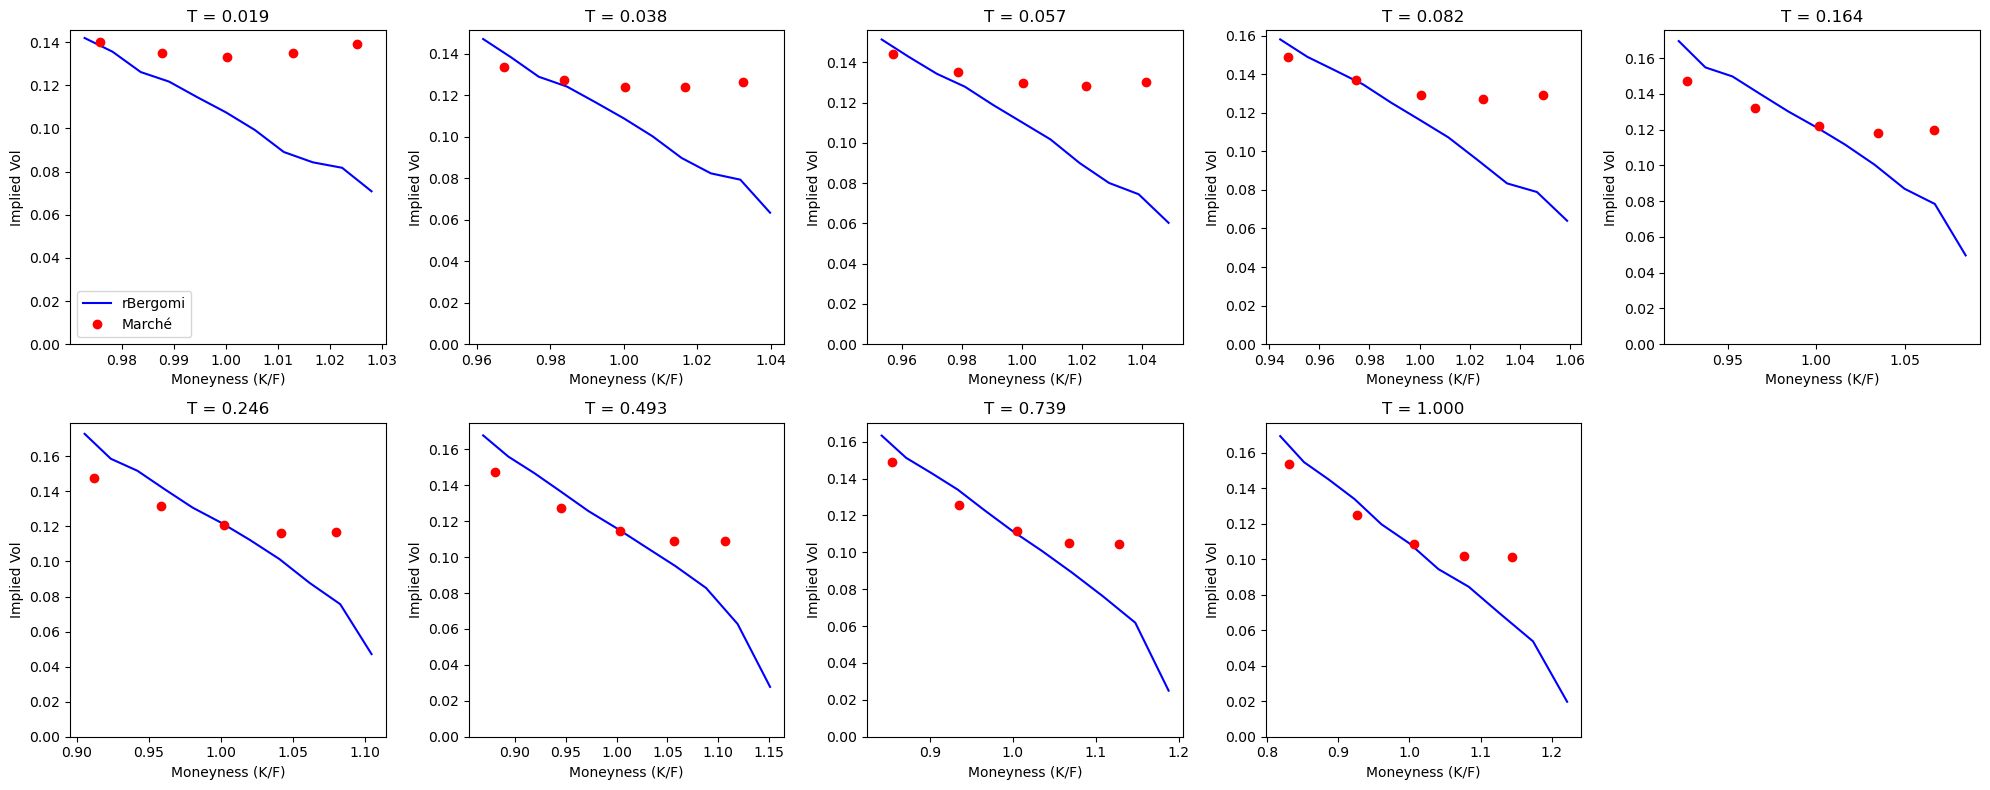

In [33]:
params_scaled         = myscale(calibrated_params)
predicted_vols_scaled = NeuralNetwork(params_scaled)
predicted_vols        = xinversetransform(predicted_vols_scaled)
market_vols           = real_vols_flat

mae  = np.mean(np.abs(predicted_vols - market_vols))
rmse = np.sqrt(np.mean((predicted_vols - market_vols)**2))
print(f"MAE={mae*100:.2f}%  RMSE={rmse*100:.2f}%")

tenors = ['1W', '2W', '3W', '1M', '2M', '3M', '6M', '9M', '1Y']
deltas = ['10d', '25d', '50d', '75d', '90d']
T_map  = dict(zip(tenors, maturities))

plt.figure(figsize=(20, 8))
for i in range(maturities_dim):
    plt.subplot(2, 5, i+1)
    T  = maturities[i]
    ks = get_strikes(T)

    plt.plot(ks, predicted_vols[i*strikes_dim:(i+1)*strikes_dim], '-b', label="rBergomi")

    ten = tenors[i]
    vrais_x, vrais_y = [], []
    for d in deltas:
        vol = row[f'mid{d}_{ten}']
        if vol > 1.0:
            vol /= 100.0
        vrais_x.append(row[f'mon{d}_{ten}'])
        vrais_y.append(vol)
    plt.plot(vrais_x, vrais_y, 'or', markersize=6, label="Marché")

    plt.title(f"T = {T:.3f}")
    plt.xlabel("Moneyness (K/F)")
    plt.ylabel("Implied Vol")
    plt.ylim(bottom=0.0)
    if i == 0:
        plt.legend()

plt.tight_layout()
plt.show()

In [38]:
real_market_df = pd.read_csv("FX_Training_Data_ZScores_Clean.csv")

tenors = ['1W', '2W', '3W', '1M', '2M', '3M', '6M', '9M', '1Y']
deltas = ['10d', '25d', '50d', '75d', '90d']
T_map  = dict(zip(tenors, maturities))

# Grille cible pré-calculée une seule fois pour toute la boucle
grid_T_list, grid_M_list = [], []
for T in maturities:
    for K in get_strikes(T):
        grid_T_list.append(T)
        grid_M_list.append(K)
grid_T_arr = np.array(grid_T_list)
grid_M_arr = np.array(grid_M_list)

def CostFuncLS_Market(x, target, w):
    return (NeuralNetwork(x) - target) * w

def JacobianLS_Market(x, target, w):
    return NeuralNetworkGradient(x).T * w[:, np.newaxis]

historical_calibrations = []
start_time = time.time()
print(f"Calibration historique — {len(real_market_df)} jours...")

prev_x = None
for idx, row in real_market_df.iterrows():
    init_guess = prev_x if prev_x is not None else np.zeros(12)
    
    calibrated_params = myinverse(result.x)
    # A. Interpolation des 45 points marché → grille 99 points z-scores
    obs_points, obs_vols = [], []
    for ten in tenors:
        T = T_map[ten]
        for d in deltas:
            vol = row[f'mid{d}_{ten}']
            if vol > 1.0:
                vol /= 100.0
            obs_points.append([T, row[f'mon{d}_{ten}']])
            obs_vols.append(vol)

    real_vols_lin = griddata(obs_points, obs_vols, (grid_T_arr, grid_M_arr), method='linear')
    valid_mask    = ~np.isnan(real_vols_lin)
    weights       = valid_mask.astype(float)

    if np.isnan(real_vols_lin).any():
        real_vols_near = griddata(obs_points, obs_vols, (grid_T_arr, grid_M_arr), method='nearest')
        real_vols_flat = np.where(np.isnan(real_vols_lin), real_vols_near, real_vols_lin)
    else:
        real_vols_flat = real_vols_lin

    real_vols_scaled = scale2.transform(real_vols_flat.reshape(1, -1))[0]

    # B. Calibration LM (warm-start : remplacer np.zeros(12) par prev_result_x)
    result = scipy.optimize.least_squares(
        CostFuncLS_Market, init_guess, JacobianLS_Market,
        args=(real_vols_scaled, weights),
        bounds=([-1.0] * 12, [1.0] * 12),
        method='trf', gtol=1e-10, xtol=1e-10, ftol=1e-10,
    )
    init_guess = result.x 

    # C. Erreur sur les points valides uniquement
    predicted_vols = xinversetransform(NeuralNetwork(result.x))
    rmse = np.sqrt(np.mean((predicted_vols[valid_mask] - real_vols_flat[valid_mask])**2))
    mae  = np.mean(np.abs(predicted_vols[valid_mask] - real_vols_flat[valid_mask]))

    day_results = {'Date': row['quote_date'], 'RMSE': rmse, 'MAE': mae,
                   'nu': calibrated_params[9], 'rho': calibrated_params[10], 'H': calibrated_params[11]}
    for i, t in enumerate(maturities):
        day_results[f'xi_{t:.3f}'] = calibrated_params[i]
    historical_calibrations.append(day_results)

    if (idx + 1) % 50 == 0:
        print(f"{idx + 1}/{len(real_market_df)} jours calibrés...")

results_df = pd.DataFrame(historical_calibrations)
results_df.to_csv("rBergomi_Historical_Parameters_EURUSD.csv", index=False)

elapsed = time.time() - start_time
print(f"Terminé en {elapsed/60:.2f} min — RMSE moyen : {results_df['RMSE'].mean()*100:.3f}%")

Calibration historique — 1185 jours...
50/1185 jours calibrés...
100/1185 jours calibrés...
150/1185 jours calibrés...
200/1185 jours calibrés...
250/1185 jours calibrés...
300/1185 jours calibrés...
350/1185 jours calibrés...
400/1185 jours calibrés...
450/1185 jours calibrés...
500/1185 jours calibrés...
550/1185 jours calibrés...
600/1185 jours calibrés...
650/1185 jours calibrés...
700/1185 jours calibrés...
750/1185 jours calibrés...
800/1185 jours calibrés...
850/1185 jours calibrés...
900/1185 jours calibrés...
950/1185 jours calibrés...
1000/1185 jours calibrés...
1050/1185 jours calibrés...
1100/1185 jours calibrés...
1150/1185 jours calibrés...
Terminé en 5.03 min — RMSE moyen : 0.265%


C:\Users\ERWAN\AppData\Local\Temp\ipykernel_36204\853750604.py:55: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


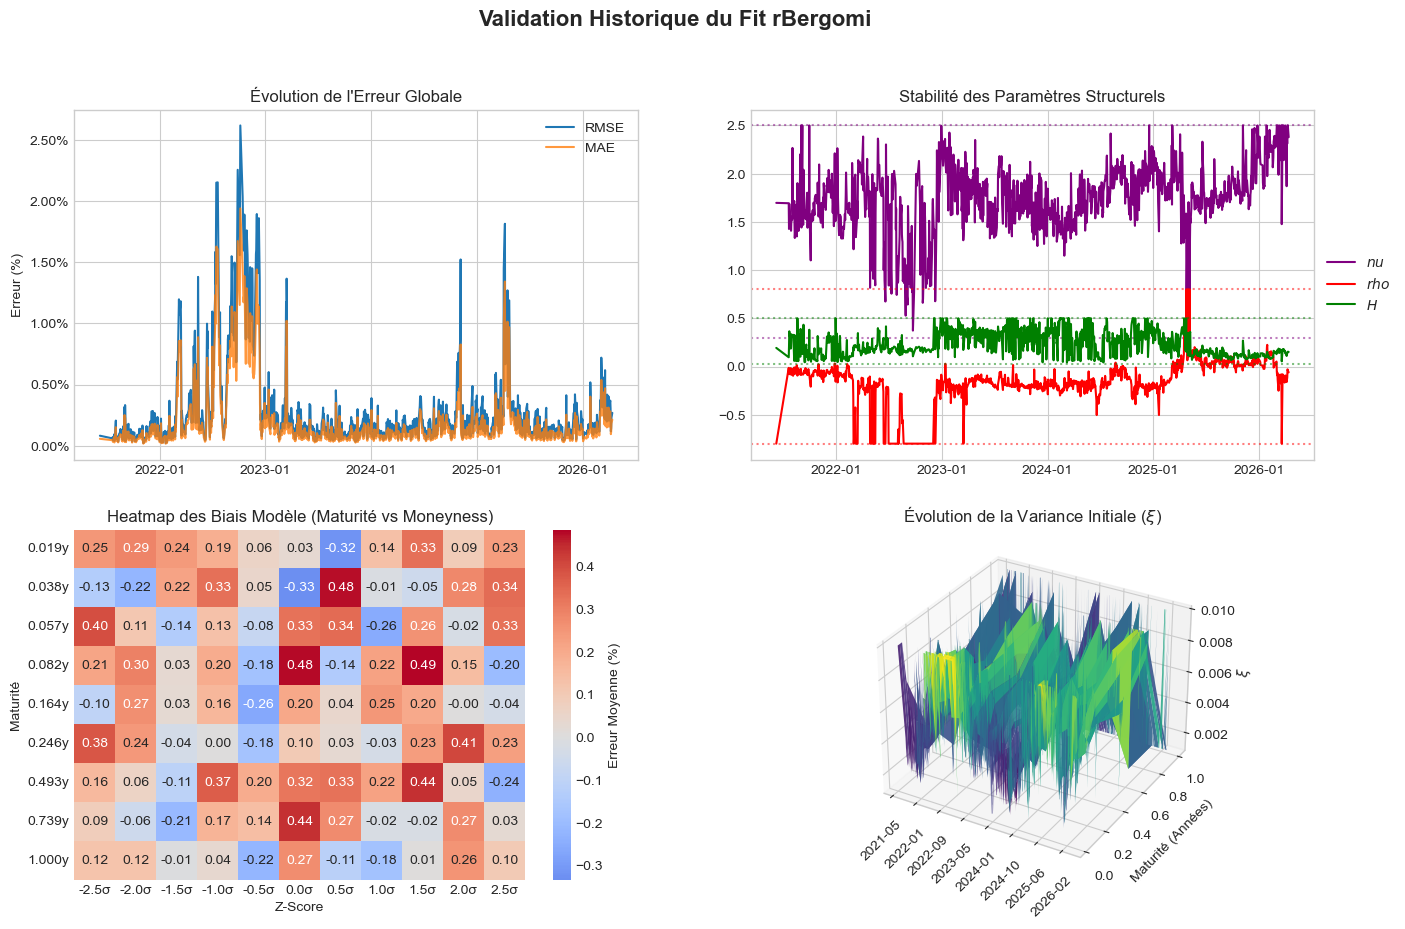

In [39]:
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv("rBergomi_Historical_Parameters_EURUSD.csv")
df['Date'] = pd.to_datetime(df['Date'])
dates = df['Date']

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Validation Historique du Fit rBergomi", fontsize=16, fontweight='bold', y=0.98)

# RMSE & MAE
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(dates, df['RMSE'] * 100, label='RMSE', color='#1f77b4', linewidth=1.5)
ax1.plot(dates, df['MAE']  * 100, label='MAE',  color='#ff7f0e', linewidth=1.5, alpha=0.8)
ax1.set_title("Évolution de l'Erreur Globale", fontsize=12)
ax1.set_ylabel("Erreur (%)")
ax1.yaxis.set_major_formatter(PercentFormatter(decimals=2))
ax1.legend(loc='upper right')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Paramètres structurels avec bornes
ax2 = fig.add_subplot(2, 2, 2)
for param, color, lo, hi in [('nu', 'purple', 0.3, 2.5), ('rho', 'red', -0.8, 0.8), ('H', 'green', 0.025, 0.5)]:
    ax2.plot(dates, df[param], label=f'${param}$', color=color, linewidth=1.5)
    ax2.axhline(lo, color=color, linestyle=':', alpha=0.5)
    ax2.axhline(hi, color=color, linestyle=':', alpha=0.5)
ax2.set_title("Stabilité des Paramètres Structurels", fontsize=12)
ax2.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Heatmap des biais (à remplacer par la moyenne temporelle réelle des résidus)
ax3 = fig.add_subplot(2, 2, 3)
z_scores   = np.linspace(-2.5, 2.5, 11)
maturities = [0.019, 0.038, 0.057, 0.082, 0.164, 0.246, 0.493, 0.739, 1.0]
dummy_errors = np.random.normal(loc=0.001, scale=0.002, size=(len(maturities), len(z_scores)))
sns.heatmap(dummy_errors * 100, ax=ax3, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", cbar_kws={'label': 'Erreur Moyenne (%)'},
            xticklabels=[f"{z:.1f}σ" for z in z_scores],
            yticklabels=[f"{t:.3f}y" for t in maturities])
ax3.set_title("Heatmap des Biais Modèle (Maturité vs Moneyness)", fontsize=12)
ax3.set_xlabel("Z-Score")
ax3.set_ylabel("Maturité")

# Surface 3D de la courbe xi(t, T)
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
xi_cols = [col for col in df.columns if col.startswith('xi_')]
X, Y = np.meshgrid(mdates.date2num(dates), maturities)
ax4.plot_surface(X, Y, df[xi_cols].values.T, cmap='viridis', edgecolor='none', alpha=0.9)
ax4.set_title(r"Évolution de la Variance Initiale ($\xi$)", fontsize=12)
ax4.set_ylabel("Maturité (Années)")
ax4.set_zlabel(r"$\xi$")
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
for label in ax4.get_xticklabels():
    label.set_rotation(45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("rBergomi_Historical_Validation_Dashboard.png", dpi=300)
plt.show()